# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [3]:
#Variaveis de controle
num_replys_anotados = 150
num_quotes_anotados = 150
num_originals_anotados = 150

# **Pares Tweets-Reply**

In [4]:
# baixando dataset para o collab
import gdown

file_class_caio = "1BZ1UGqv7IlaA7AGCDJG0nqOt2-ZrObAc"
file_class_victor = "16oo75d3yqJJS3rBXPIbKbFYfi7GzLQpk"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Aborto_reply_caio.csv", quiet=False)
gdown.download(url_2, "Aborto_reply_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1BZ1UGqv7IlaA7AGCDJG0nqOt2-ZrObAc
To: /content/Aborto_reply_caio.csv
100%|██████████| 514k/514k [00:00<00:00, 108MB/s]
Downloading...
From: https://drive.google.com/uc?id=16oo75d3yqJJS3rBXPIbKbFYfi7GzLQpk
To: /content/Aborto_reply_victor.csv
100%|██████████| 514k/514k [00:00<00:00, 102MB/s]


'Aborto_reply_victor.csv'

In [5]:
#carregando o dataset
df_caio = pd.read_csv ("Aborto_reply_caio.csv")
df_victor = pd.read_csv ("Aborto_reply_victor.csv")

In [6]:
#numero total de instancias no dataset
df_caio.shape

(2051, 4)

In [7]:
#numero total de instancias no dataset
df_victor.shape

(2051, 4)

In [8]:
df_caio.head(20)

,tweet_1,tweet_2,Class,Conflict
0,"O aborto tem q ser permitido, pra evitar q cri...","VC não acha melhor a bebê nascer não, vai ter ...",1,1.0
1,"Bora subir, robozada? #AbortoNao",#AbortoNAO vida sim,1,0.0
2,STF quer aplicar a medida enquanto a gente não...,Que Porra é essa ? #AbortoNao,1,0.0
3,Enquanto lutamos pela nossa vida contra o covi...,Assassinato nunca! #AbortoNAO,1,0.0
4,STF quer aplicar a medida enquanto a gente não...,Vergonha desse STF #AbortoNAO,1,0.0
5,"Bora subir, robozada? #AbortoNao",Gostaria de informar que devido a grande reper...,1,0.0
6,É fácil defender o aborto sendo que você já na...,Há se as pessoas sobessem o mal que trszem par...,1,0.0
7,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Linda passagem da Bíblia. #AbortoNAO,1,0.0
8,Bolsominions estão revoltados pq STF pode perm...,É sobre as mulheres terem escolha. Se uma gest...,1,0.0
9,"O que a Bíblia fala sobre o aborto? ""Antes qu...",#AbortoNAO Minha nossa! Isso não!,1,-1.0


In [9]:
df_victor.head(20)

,tweet_1,tweet_2,Class,Conflict
0,"O aborto tem q ser permitido, pra evitar q cri...","VC não acha melhor a bebê nascer não, vai ter ...",1,1.0
1,"Bora subir, robozada? #AbortoNao",#AbortoNAO vida sim,1,0.0
2,STF quer aplicar a medida enquanto a gente não...,Que Porra é essa ? #AbortoNao,1,0.0
3,Enquanto lutamos pela nossa vida contra o covi...,Assassinato nunca! #AbortoNAO,1,0.0
4,STF quer aplicar a medida enquanto a gente não...,Vergonha desse STF #AbortoNAO,1,0.0
5,"Bora subir, robozada? #AbortoNao",Gostaria de informar que devido a grande reper...,1,-1.0
6,É fácil defender o aborto sendo que você já na...,Há se as pessoas sobessem o mal que trszem par...,1,0.0
7,"O que a Bíblia fala sobre o aborto? ""Antes qu...",Linda passagem da Bíblia. #AbortoNAO,1,0.0
8,Bolsominions estão revoltados pq STF pode perm...,É sobre as mulheres terem escolha. Se uma gest...,1,0.0
9,"O que a Bíblia fala sobre o aborto? ""Antes qu...",#AbortoNAO Minha nossa! Isso não!,1,-1.0


In [10]:
df_remaining_reply = df_caio.iloc[num_replys_anotados:,:]
df_caio = df_caio.iloc[:num_replys_anotados,:]
df_victor = df_victor.iloc[:num_replys_anotados,:]

In [11]:
df_caio

,tweet_1,tweet_2,Class,Conflict
0,"O aborto tem q ser permitido, pra evitar q cri...","VC não acha melhor a bebê nascer não, vai ter ...",1,1.0
1,"Bora subir, robozada? #AbortoNao",#AbortoNAO vida sim,1,0.0
2,STF quer aplicar a medida enquanto a gente não...,Que Porra é essa ? #AbortoNao,1,0.0
3,Enquanto lutamos pela nossa vida contra o covi...,Assassinato nunca! #AbortoNAO,1,0.0
4,STF quer aplicar a medida enquanto a gente não...,Vergonha desse STF #AbortoNAO,1,0.0
...,...,...,...,...
145,Vamos começar a pressão ao STF já. #AbortoNAO,Vamos lá! #AbortoNAO,1,0.0
146,#AbortoNAO chegando ao topo dos TT's. Vamos ...,É inacreditável! #AbortoNAO,1,0.0
147,Vamos começar a pressão ao STF já. #AbortoNAO,Fala pra mim .... Mais essa #AbortoNao,1,0.0
148,Vamos começar a pressão ao STF já. #AbortoNAO,#AbortoNao vamos pressionar juntos!,1,0.0


In [12]:
df_victor

,tweet_1,tweet_2,Class,Conflict
0,"O aborto tem q ser permitido, pra evitar q cri...","VC não acha melhor a bebê nascer não, vai ter ...",1,1.0
1,"Bora subir, robozada? #AbortoNao",#AbortoNAO vida sim,1,0.0
2,STF quer aplicar a medida enquanto a gente não...,Que Porra é essa ? #AbortoNao,1,0.0
3,Enquanto lutamos pela nossa vida contra o covi...,Assassinato nunca! #AbortoNAO,1,0.0
4,STF quer aplicar a medida enquanto a gente não...,Vergonha desse STF #AbortoNAO,1,0.0
...,...,...,...,...
145,Vamos começar a pressão ao STF já. #AbortoNAO,Vamos lá! #AbortoNAO,1,0.0
146,#AbortoNAO chegando ao topo dos TT's. Vamos ...,É inacreditável! #AbortoNAO,1,0.0
147,Vamos começar a pressão ao STF já. #AbortoNAO,Fala pra mim .... Mais essa #AbortoNao,1,0.0
148,Vamos começar a pressão ao STF já. #AbortoNAO,#AbortoNao vamos pressionar juntos!,1,0.0


In [13]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [14]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [15]:
confusion

array([[121.,   1.,   1.],
       [  1.,  22.,   0.],
       [  2.,   1.,   1.]])

In [16]:
idx_diff

[5, 79, 104, 134, 140, 149]

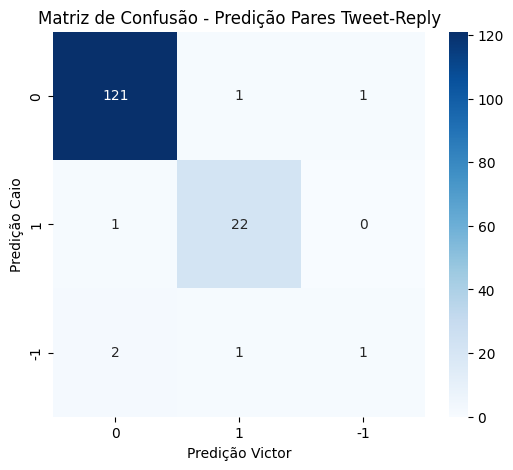

In [17]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Reply")
plt.show()

In [18]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  Bora subir, robozada?   #AbortoNao
Tweet 2:  Gostaria de informar que devido a grande repercussão do vídeo de Araraquara, o jornalista foi demitido. Mas queremos mais, muito mais; queremos que o Ministério Público investigue todos os contratos feitos entre a prefeitura, as mídias, rádio e televisão de Araraquara #AbortoNAO
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Vamos subir #AbortoNao .  STF quer aprovar medida em plena pandemia.
Tweet 2:  ok mo calma aí  #AbortoSim
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  Obesidade mata muito muito muito mais que aborto e vcs celebram obesidade. Então não venha com papo furado.
Tweet 2:  Questão de saúde, diz o panguado q num sabe q morrem mais mulheres por câncer de mama, desnutrição e tabagismo do vagabunda q tentou aborto pq deu a ppk na balada p um vagabundo. #AbortoNAO
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tweet 1:  É muita gente h

In [80]:
# para contagem das divergências e convergências
sum_con = 0
sum_div = 0

In [81]:
cont_div = len(idx_diff)
cont_con = df_caio.shape[0] - cont_div

print("Divergentes: ", cont_div)
print("Convergentes: ", cont_con)

sum_div += cont_div
sum_con += cont_con

print("Total de divergentes: ", sum_div)
print("Total de convergentes: ", sum_con)

Divergentes:  6
Convergentes:  144
Total de divergentes:  6
Total de convergentes:  144


# **Pares Tweets-Quotes**

In [19]:
file_class_caio_quotes = "1yWYkXSwkkcH0ub_zIX30ZUGkEYSnLqQi"
file_class_victor_quotes = "1gXbXkJWbnrcipbLXFXRNg5s9ySU4muQs"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_quotes}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_quotes}"

gdown.download(url_1, "Aborto_quotes_caio.csv", quiet=False)
gdown.download(url_2, "Aborto_quotes_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1yWYkXSwkkcH0ub_zIX30ZUGkEYSnLqQi
To: /content/Aborto_quotes_caio.csv
100%|██████████| 775k/775k [00:00<00:00, 103MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gXbXkJWbnrcipbLXFXRNg5s9ySU4muQs
To: /content/Aborto_quotes_victor.csv
100%|██████████| 775k/775k [00:00<00:00, 115MB/s]


'Aborto_quotes_victor.csv'

In [20]:
df_caio_quotes = pd.read_csv ("Aborto_quotes_caio.csv")
df_victor_quotes = pd.read_csv ("Aborto_quotes_victor.csv")

In [21]:
df_remaining_quotes = df_caio_quotes.iloc[num_quotes_anotados:,:]
df_caio_quotes = df_caio_quotes.iloc[:num_quotes_anotados,:]
df_victor_quotes = df_victor_quotes.iloc[:num_quotes_anotados,:]

In [22]:
confusion_quotes = np.zeros((3,3))

In [23]:
idx_diff_quotes = []

In [24]:
for i in range(df_caio_quotes.shape[0]):
  caio = int(df_caio_quotes.iloc[i]["Conflict"])
  victor = int(df_victor_quotes.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_quotes[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_quotes.append(i)


In [25]:
confusion_quotes

array([[102.,   2.,   5.],
       [  0.,  36.,   3.],
       [  1.,   0.,   1.]])

In [26]:
idx_diff_quotes

[11, 24, 33, 34, 66, 70, 82, 89, 101, 127, 129]

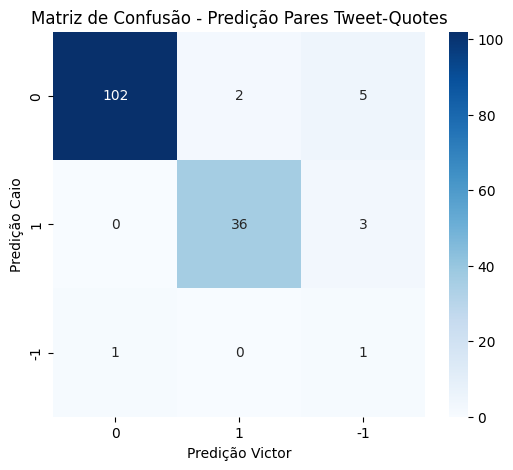

In [27]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_quotes, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet-Quotes")
plt.show()

In [28]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_quotes)):
  print("Tweet 1: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_1"])
  print("Tweet 2: ", df_caio_quotes.loc[idx_diff_quotes[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_quotes.loc[idx_diff_quotes[i], "Conflict"])])
  print()

Tweet 1:  A quem caberá decidir sobre a vida de um anjo? Não está se discutindo o direito da mulher interromper uma gravidez indesejada, pois se isso ela cometer a sua pena será “sui gêneris” . O que está se discutindo são  os lucros da clínicas de aborto que desejam faturar livremente.
Tweet 2:  A mulher tem direito sobre SUA vida e responsabilidade para cuidar e resguardá-la contra todo o mal; tem maior responsabilidade ainda para proteger a VIDA de OUTRO SER, principalmente, se este SER estiver sendo gestado em seu ventre! #AbortoNao
Classificação Caio:  Conflito
Classificação Victor:  Indeterminado

Tweet 1:  É muita gente hipócrita e sem noção usando a #AbortoNAO a maioria homens eleitores do bozo e o resto que dão mais valor a um feto do que a vida de uma mulher. O corpo é MEU e absolutamente TUDO nele TAMBÉM É MEU a decisão é MINHA SIM portanto #AbortoSim
Tweet 2:  Sem útero, sem opinião = Se a sua foto de perfil é de anime, a sua opinião não é válida  Ambos merda
Classificação 

In [82]:
cont_div = len(idx_diff_quotes)
cont_con = df_caio_quotes.shape[0] - cont_div

print("Divergentes: ", cont_div)
print("Convergentes: ", cont_con)

sum_div += cont_div
sum_con += cont_con

print("Total de divergentes: ", sum_div)
print("Total de convergentes: ", sum_con)

Divergentes:  11
Convergentes:  139
Total de divergentes:  17
Total de convergentes:  283


# **Pares Tweets Originals**

In [29]:
file_class_caio_originals = "152ehKPqF1K_JPCpMFFblfkNoF8IDuOXk"
file_class_victor_originals = "16DRf743OydUbjsqq3npzu42SqHp63J3q"
url_1 = f"https://drive.google.com/uc?id={file_class_caio_originals}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor_originals}"

gdown.download(url_1, "Aborto_originals_caio.csv", quiet=False)
gdown.download(url_2, "Aborto_originals_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=152ehKPqF1K_JPCpMFFblfkNoF8IDuOXk
To: /content/Aborto_originals_caio.csv
100%|██████████| 2.75M/2.75M [00:00<00:00, 235MB/s]
Downloading...
From: https://drive.google.com/uc?id=16DRf743OydUbjsqq3npzu42SqHp63J3q
To: /content/Aborto_originals_victor.csv
100%|██████████| 2.75M/2.75M [00:00<00:00, 185MB/s]


'Aborto_originals_victor.csv'

In [30]:
df_caio_originals = pd.read_csv ("Aborto_originals_caio.csv")
df_victor_originals = pd.read_csv ("Aborto_originals_victor.csv")

In [31]:
df_remaining_originals = df_caio_originals.iloc[num_originals_anotados:,:]
df_caio_originals = df_caio_originals.iloc[:num_originals_anotados,:]
df_victor_originals = df_victor_originals.iloc[:num_originals_anotados,:]

In [32]:
confusion_originals = np.zeros((3,3))

In [33]:
idx_diff_originals = []

In [34]:
for i in range(df_caio_originals.shape[0]):
  caio = int(df_caio_originals.iloc[i]["Conflict"])
  victor = int(df_victor_originals.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion_originals[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff_originals.append(i)

In [35]:
confusion_originals

array([[74., 14.,  7.],
       [ 4., 46.,  3.],
       [ 0.,  1.,  1.]])

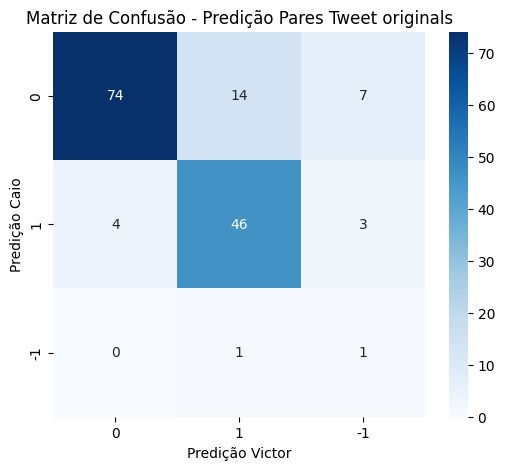

In [36]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion_originals, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares Tweet originals")
plt.show()

In [37]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff_originals)):
  print("Tweet 1: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_1"])
  print("Tweet 2: ", df_caio_originals.loc[idx_diff_originals[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio_originals.loc[idx_diff_originals[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor_originals.loc[idx_diff_originals[i], "Conflict"])])
  print()

Tweet 1:  #AbortoSim só pra subir a tag
Tweet 2:  O oportunismo da morte.  #AbortoNao
Classificação Caio:  Conflito
Classificação Victor:  Indeterminado

Tweet 1:  O Brasil vai ter que Ucranizar. #AbortoNAO #FiqueEmCasaMandetta #ChegouHoraDoChega  #BolsonaroEstavaCerto  #MonarquiaJa  #olavotemrazao
Tweet 2:  #AbortoSim #abortonao aproveitando que a discussão veio a tona, recomendo que assistam esse video do Canal do Slow:   E nessa casa nós somos #AbortoSIM
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  Se um feto fosse um indivíduo dotado de direitos, incluindo o direito à vida, mulheres grávidas poderiam fazer seguro de vida ou até passar propriedades para eles. Teriam também desconto no imposto de renda por terem um dependente, já que fetos são “bebês”. #abortosim
Tweet 2:  STF aproveitando crise para legalizar aborto.  Não podemos permitir. #AbortoNao
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tweet 1:  Em meio à pandemia e

In [83]:
cont_div = len(idx_diff_originals)
cont_con = df_caio_originals.shape[0] - cont_div

print("Divergentes: ", cont_div)
print("Convergentes: ", cont_con)

sum_div += cont_div
sum_con += cont_con

print("Total de divergentes: ", sum_div)
print("Total de convergentes: ", sum_con)

Divergentes:  29
Convergentes:  121
Total de divergentes:  46
Total de convergentes:  404


In [38]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_replys = df_caio.drop('Conflict', axis = 1)
df_replys['Conflict_Caio'] = df_caio['Conflict']
df_replys['Conflict_Victor'] = df_victor['Conflict']

In [39]:
df_replys

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,"O aborto tem q ser permitido, pra evitar q cri...","VC não acha melhor a bebê nascer não, vai ter ...",1,1.0,1.0
1,"Bora subir, robozada? #AbortoNao",#AbortoNAO vida sim,1,0.0,0.0
2,STF quer aplicar a medida enquanto a gente não...,Que Porra é essa ? #AbortoNao,1,0.0,0.0
3,Enquanto lutamos pela nossa vida contra o covi...,Assassinato nunca! #AbortoNAO,1,0.0,0.0
4,STF quer aplicar a medida enquanto a gente não...,Vergonha desse STF #AbortoNAO,1,0.0,0.0
...,...,...,...,...,...
145,Vamos começar a pressão ao STF já. #AbortoNAO,Vamos lá! #AbortoNAO,1,0.0,0.0
146,#AbortoNAO chegando ao topo dos TT's. Vamos ...,É inacreditável! #AbortoNAO,1,0.0,0.0
147,Vamos começar a pressão ao STF já. #AbortoNAO,Fala pra mim .... Mais essa #AbortoNao,1,0.0,0.0
148,Vamos começar a pressão ao STF já. #AbortoNAO,#AbortoNao vamos pressionar juntos!,1,0.0,0.0


In [40]:
#Organizando classificações de conflitos em quotes de Caio e Victor em um unico DF
df_quotes = df_caio_quotes.drop('Conflict',axis=1)
df_quotes['Conflict_Caio'] = df_caio_quotes['Conflict']
df_quotes['Conflict_Victor'] = df_victor_quotes['Conflict']

In [41]:
df_quotes

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,STF quer aplicar a medida enquanto a gente não...,"Independente se você tem religião ou não, o tr...",2,0.0,0.0
1,"Eu peço a quem for a favor do aborto, para ref...",eu peço para que você faça mais por crianças j...,2,1.0,1.0
2,"Toffoli, um lacaio da OMS, pautou ADI do abort...",vc é um homem cis q se sua namorada engravidar...,2,1.0,1.0
3,"Médico pedófilo, Fábio Duarte, estava preso p/...",Difícil demais viver nesse País! A que ponto c...,2,0.0,0.0
4,#AbortoNao A hidroxicloroquina pode ter efeito...,Primeiramente #foradoria segundamente nao somo...,2,0.0,0.0
...,...,...,...,...,...
145,CURIOSIDADE: 100% das pessoas que usam a hasht...,#AbortoNAO E que se danem todos os aborteiro...,2,0.0,0.0
146,superfatura e esconde? Mas alguém encontrou !,Queremos transparência nos gastos referentes a...,2,0.0,0.0
147,"Se vc é cristão, pq invés de subir a #AbortoNA...",NA HORA DE SABER DA PÁGINA 5 AO 32 DO KAMASSUT...,2,1.0,1.0
148,"MP denuncia perda de 2,7 milhões de bolsas de ...","Tem que investigar mesmo MP, . O BRASIL não e...",2,0.0,0.0


In [42]:
#Organizando classificações de conflitos em originals de Caio e Victor em um unico DF
df_originals = df_caio_originals.drop('Conflict',axis=1)
df_originals['Conflict_Caio'] = df_caio_originals['Conflict']
df_originals['Conflict_Victor'] = df_victor_originals['Conflict']

In [43]:
df_originals

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,0,0.0,0.0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,0,1.0,1.0
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,0,0.0,0.0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,0,1.0,1.0
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,0,0.0,0.0
...,...,...,...,...,...
145,é oq que esse povo ta falando de #AbortoNao? a...,"porque ao invés de criar a hastag #AbortoNao, ...",0,0.0,0.0
146,"Homens palpitando sobre aborto, “pipipopo pres...",O mais irônico da AbortoSim vs #AbortoNao É ...,0,0.0,1.0
147,"#AbortoSim imundos, lixos, HIPÓCRITAS. Imagina...",#AbortoNao é obrigatório #pas,0,0.0,-1.0
148,Os caras trabalham só pra atrasar o Brasil dos...,"""A mAiS o FeTo NãO sEnTe DoR"" Existem pessoas...",0,0.0,0.0


In [44]:
#concatenando os datasets parciais:
df_aborto_classificado = pd.concat([df_originals, df_replys, df_quotes], ignore_index=True, axis = 0)
df_aborto_classificado

,tweet_1,tweet_2,Class,Conflict_Caio,Conflict_Victor
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,0,0.0,0.0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,0,1.0,1.0
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,0,0.0,0.0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,0,1.0,1.0
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,0,0.0,0.0
...,...,...,...,...,...
445,CURIOSIDADE: 100% das pessoas que usam a hasht...,#AbortoNAO E que se danem todos os aborteiro...,2,0.0,0.0
446,superfatura e esconde? Mas alguém encontrou !,Queremos transparência nos gastos referentes a...,2,0.0,0.0
447,"Se vc é cristão, pq invés de subir a #AbortoNA...",NA HORA DE SABER DA PÁGINA 5 AO 32 DO KAMASSUT...,2,1.0,1.0
448,"MP denuncia perda de 2,7 milhões de bolsas de ...","Tem que investigar mesmo MP, . O BRASIL não e...",2,0.0,0.0


In [45]:
df_aborto_classificado.to_csv("aborto_classificado.csv", index=False, encoding="utf-8")
files.download("aborto_classificado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das divergencias**

In [46]:
div_reply = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_reply['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div_reply['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div_reply['Conflict'] = np.nan
div_quotes = df_caio_quotes.iloc[idx_diff_quotes].drop('Conflict', axis=1)
div_quotes['Conflict_caio'] = df_caio_quotes['Conflict'].iloc[idx_diff_quotes].astype(int)
div_quotes['Conflict_victor'] = df_victor_quotes['Conflict'].iloc[idx_diff_quotes].astype(int)
div_quotes['Conflict'] = np.nan
div_originals = df_caio_originals.iloc[idx_diff_originals].drop('Conflict', axis=1)
div_originals['Conflict_caio'] = df_caio_originals['Conflict'].iloc[idx_diff_originals].astype(int)
div_originals['Conflict_victor'] = df_victor_originals['Conflict'].iloc[idx_diff_originals].astype(int)
div_originals['Conflict'] = np.nan

In [47]:
div_reply.shape

(6, 6)

In [48]:
div_quotes.shape

(11, 6)

In [49]:
div_originals.shape

(29, 6)

In [50]:
div_aborto = pd.concat([div_originals, div_reply, div_quotes], ignore_index=True, axis = 0)

In [51]:
div_aborto.shape

(46, 6)

In [52]:
div_aborto_final = div_aborto.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_aborto_final

,tweet_1,tweet_2,Class,Conflict
0,#AbortoSim só pra subir a tag,O oportunismo da morte. #AbortoNao,0,NaN
1,O Brasil vai ter que Ucranizar. #AbortoNAO #Fi...,#AbortoSim #abortonao aproveitando que a discu...,0,NaN
2,Se um feto fosse um indivíduo dotado de direit...,STF aproveitando crise para legalizar aborto. ...,0,NaN
3,Em meio à pandemia e palavras de todos em preo...,#AbortoSim Eu vendo esses macho falando merda ...,0,NaN
4,#AbortoSim veio na hora certa o trending,Mas eu sinto que o maior destruidor da paz hoj...,0,NaN
5,Boa noite Primeiro #AbortoNao Segundo Cada dia...,#AbortoSim milhares de mulheres morrem todo...,0,NaN
6,As pessoas acham q quando dizemos #AbortoSim n...,STF cuidado vcs estão puxando a corda #AbortoNao,0,NaN
7,#AbortoNao querem acabar com o aborto? Fácil ...,Vc que prática esse tipo de assassinato de um ...,0,NaN
8,Só eu q sou bem foda-se em questão de aborto? ...,E aquele papo de ter que ficar em casa pra pre...,0,NaN
9,#AbortoNao Aborto deve ser feito em casos de: ...,e aí libfem já se posicionou #AbortoSIM hoje? ...,0,NaN


In [53]:
div_aborto_final.to_csv("divergencias_aborto.csv", index=False, encoding="utf-8")
files.download("divergencias_aborto.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [54]:
conv_reply = df_caio.drop(index=idx_diff, errors='ignore')
conv_quotes = df_caio_quotes.drop(index=idx_diff_quotes, errors='ignore')
conv_originals = df_caio_originals.drop(index=idx_diff_originals, errors='ignore')

In [55]:
conv_reply.shape

(144, 4)

In [56]:
conv_aborto = pd.concat([conv_originals, conv_reply, conv_quotes], ignore_index=True, axis = 0)

In [57]:
conv_aborto

,tweet_1,tweet_2,Class,Conflict
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,0,0.0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,0,1.0
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,0,0.0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,0,1.0
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,0,0.0
...,...,...,...,...
399,CURIOSIDADE: 100% das pessoas que usam a hasht...,#AbortoNAO E que se danem todos os aborteiro...,2,0.0
400,superfatura e esconde? Mas alguém encontrou !,Queremos transparência nos gastos referentes a...,2,0.0
401,"Se vc é cristão, pq invés de subir a #AbortoNA...",NA HORA DE SABER DA PÁGINA 5 AO 32 DO KAMASSUT...,2,1.0
402,"MP denuncia perda de 2,7 milhões de bolsas de ...","Tem que investigar mesmo MP, . O BRASIL não e...",2,0.0


In [58]:
#adicionando as classificações do professor
file_class_aborto_prof = "1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B"
url = f"https://drive.google.com/uc?id={file_class_aborto_prof}"
gdown.download(url, "aborto_class_prof.csv", quiet=False)
df_class_prof = pd.read_csv ("aborto_class_prof.csv")

Downloading...
From: https://drive.google.com/uc?id=1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B
To: /content/aborto_class_prof.csv
100%|██████████| 12.4k/12.4k [00:00<00:00, 29.4MB/s]


In [59]:
df_class_prof

,tweet_1,tweet_2,Class,Conflict
0,#AbortoSim só pra subir a tag,O oportunismo da morte. #AbortoNao,0,1
1,O Brasil vai ter que Ucranizar. #AbortoNAO #Fi...,#AbortoSim #abortonao aproveitando que a discu...,0,1
2,Se um feto fosse um indivíduo dotado de direit...,STF aproveitando crise para legalizar aborto. ...,0,0
3,Em meio à pandemia e palavras de todos em preo...,#AbortoSim Eu vendo esses macho falando merda ...,0,1
4,#AbortoSim veio na hora certa o trending,Mas eu sinto que o maior destruidor da paz hoj...,0,1
5,Boa noite Primeiro #AbortoNao Segundo Cada dia...,#AbortoSim milhares de mulheres morrem todo...,0,-1
6,As pessoas acham q quando dizemos #AbortoSim n...,STF cuidado vcs estão puxando a corda #AbortoNao,0,1
7,#AbortoNao querem acabar com o aborto? Fácil ...,Vc que prática esse tipo de assassinato de um ...,0,1
8,Só eu q sou bem foda-se em questão de aborto? ...,E aquele papo de ter que ficar em casa pra pre...,0,1
9,#AbortoNao Aborto deve ser feito em casos de: ...,e aí libfem já se posicionou #AbortoSIM hoje? ...,0,0


In [60]:
df_desempate = div_aborto.merge(df_class_prof, on=['tweet_1', 'tweet_2'], how='inner')
df_desempate = df_desempate.drop(columns=['Conflict_x', 'Class_y'])
df_desempate = df_desempate.rename(columns={'Class_x': 'Class', 'Conflict_y': 'Conflict_prof'})
df_desempate

,tweet_1,tweet_2,Class,Conflict_caio,Conflict_victor,Conflict_prof
0,#AbortoSim só pra subir a tag,O oportunismo da morte. #AbortoNao,0,1,-1,1
1,O Brasil vai ter que Ucranizar. #AbortoNAO #Fi...,#AbortoSim #abortonao aproveitando que a discu...,0,0,-1,1
2,Se um feto fosse um indivíduo dotado de direit...,STF aproveitando crise para legalizar aborto. ...,0,0,1,0
3,Em meio à pandemia e palavras de todos em preo...,#AbortoSim Eu vendo esses macho falando merda ...,0,-1,1,1
4,#AbortoSim veio na hora certa o trending,Mas eu sinto que o maior destruidor da paz hoj...,0,0,-1,1
5,Boa noite Primeiro #AbortoNao Segundo Cada dia...,#AbortoSim milhares de mulheres morrem todo...,0,0,1,-1
6,As pessoas acham q quando dizemos #AbortoSim n...,STF cuidado vcs estão puxando a corda #AbortoNao,0,0,-1,1
7,#AbortoNao querem acabar com o aborto? Fácil ...,Vc que prática esse tipo de assassinato de um ...,0,1,-1,1
8,Só eu q sou bem foda-se em questão de aborto? ...,E aquele papo de ter que ficar em casa pra pre...,0,0,1,1
9,#AbortoNao Aborto deve ser feito em casos de: ...,e aí libfem já se posicionou #AbortoSIM hoje? ...,0,0,1,0


In [61]:
def resolver_conflito(row):
    prof = row['Conflict_prof']
    caio = row['Conflict_caio']
    victor = row['Conflict_victor']

    if prof == caio or prof == victor:
        return prof
    else:
        return -1

df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [62]:
df_desempate

,tweet_1,tweet_2,Class,Conflict_caio,Conflict_victor,Conflict_prof,Conflict
0,#AbortoSim só pra subir a tag,O oportunismo da morte. #AbortoNao,0,1,-1,1,1
1,O Brasil vai ter que Ucranizar. #AbortoNAO #Fi...,#AbortoSim #abortonao aproveitando que a discu...,0,0,-1,1,-1
2,Se um feto fosse um indivíduo dotado de direit...,STF aproveitando crise para legalizar aborto. ...,0,0,1,0,0
3,Em meio à pandemia e palavras de todos em preo...,#AbortoSim Eu vendo esses macho falando merda ...,0,-1,1,1,1
4,#AbortoSim veio na hora certa o trending,Mas eu sinto que o maior destruidor da paz hoj...,0,0,-1,1,-1
5,Boa noite Primeiro #AbortoNao Segundo Cada dia...,#AbortoSim milhares de mulheres morrem todo...,0,0,1,-1,-1
6,As pessoas acham q quando dizemos #AbortoSim n...,STF cuidado vcs estão puxando a corda #AbortoNao,0,0,-1,1,-1
7,#AbortoNao querem acabar com o aborto? Fácil ...,Vc que prática esse tipo de assassinato de um ...,0,1,-1,1,1
8,Só eu q sou bem foda-se em questão de aborto? ...,E aquele papo de ter que ficar em casa pra pre...,0,0,1,1,1
9,#AbortoNao Aborto deve ser feito em casos de: ...,e aí libfem já se posicionou #AbortoSIM hoje? ...,0,0,1,0,0


In [63]:
df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
df_desempate

,tweet_1,tweet_2,Class,Conflict
0,#AbortoSim só pra subir a tag,O oportunismo da morte. #AbortoNao,0,1
1,O Brasil vai ter que Ucranizar. #AbortoNAO #Fi...,#AbortoSim #abortonao aproveitando que a discu...,0,-1
2,Se um feto fosse um indivíduo dotado de direit...,STF aproveitando crise para legalizar aborto. ...,0,0
3,Em meio à pandemia e palavras de todos em preo...,#AbortoSim Eu vendo esses macho falando merda ...,0,1
4,#AbortoSim veio na hora certa o trending,Mas eu sinto que o maior destruidor da paz hoj...,0,-1
5,Boa noite Primeiro #AbortoNao Segundo Cada dia...,#AbortoSim milhares de mulheres morrem todo...,0,-1
6,As pessoas acham q quando dizemos #AbortoSim n...,STF cuidado vcs estão puxando a corda #AbortoNao,0,-1
7,#AbortoNao querem acabar com o aborto? Fácil ...,Vc que prática esse tipo de assassinato de um ...,0,1
8,Só eu q sou bem foda-se em questão de aborto? ...,E aquele papo de ter que ficar em casa pra pre...,0,1
9,#AbortoNao Aborto deve ser feito em casos de: ...,e aí libfem já se posicionou #AbortoSIM hoje? ...,0,0


In [64]:
conv_aborto = pd.concat([conv_aborto, df_desempate], ignore_index=True, axis = 0)
conv_aborto

,tweet_1,tweet_2,Class,Conflict
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,0,0.0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,0,1.0
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,0,0.0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,0,1.0
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,0,0.0
...,...,...,...,...
445,"O aborto tem q ser permitido, pra evitar q cri...",(?????????????????????) caralho,2,-1.0
446,"HOMENS, calem vossas boquinhas que este assunt...",Pinto ? Alguém disse pinto? Pinto?,2,0.0
447,Mentiras contadas por Witzel na campanha começ...,Canalha sem MORAL. Mentiroso safado.,2,0.0
448,Engraçado que a maioria que está usando essa h...,Se os pais forem feios tem que abortar!!!,2,-1.0


In [65]:
conv_aborto.to_csv("convergencias_aborto.csv", index=False, encoding="utf-8")
files.download("convergencias_aborto.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dataset com pares não anotados**

In [66]:
remainig_df = pd.concat([df_remaining_originals, df_remaining_reply, df_remaining_quotes], ignore_index=True, axis = 0)
remainig_df = remainig_df.drop('Conflict', axis=1)
remainig_df

,tweet_1,tweet_2,Class
0,#AbortoNAO e os canal nas do STF estão estican...,Chega!!!!! #AbortoNao,0
1,Sério que no meio do caos eu vejo a #AbortoNAO...,Eu jamais serei contra a decisão da mulher. Se...,0
2,É um crime contra a humanidade #AbortoNao,#AbortoNao MATAR É CRIME CAPITAL! DEVERIA TER ...,0
3,eu sou a favor do aborto em alguns casos espec...,As pessoas acham q quando dizemos #AbortoSim n...,0
4,o pior é entrar na #AbortoNao é ver homem bran...,Quem escreve aborto sim seria favorável ao seu...,0
...,...,...,...
14644,Aborto não é método contraceptivo!antes de esc...,vontade de virar do avesso lendo essas coisas ...,2
14645,"O aborto tem q ser permitido, pra evitar q cri...",Então não vamos melhorar o mundo sua burra do ...,2
14646,Palavras do Nelson Teich substituto de Mande...,Faz juz...velho morre.... feto fica né? #Abo...,2
14647,Já que tenho útero posso opinar. Aborto é imor...,é um direito sim! Mais vale abortar logo do qu...,2


In [67]:
remainig_df.to_csv("aborto_nao_anotado.csv", index=False, encoding="utf-8")
files.download("aborto_nao_anotado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>